In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random

# Load the file
df = pd.read_csv('titanic.csv')

# --- 1. CLEANING THE DATA ---

# If Name is missing, delete the whole row
df = df.dropna(subset=['Name'])

# For numeric data (Age, Fare), use the MEDIAN
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# If PassengerId is missing, generate a random number (e.g., between 1000 and 2000)
df['PassengerId'] = df['PassengerId'].fillna(random.randint(1000, 2000))

# For any other categorical missing data (like Embarked), delete the missing rows
df = df.dropna(subset=['Embarked', 'Sex', 'Pclass'])

# Note: Titanic has no date column, so we skip the random date step.

print("Titanic Data Cleaned using Median and specific row deletion!")
df.head()

Titanic Data Cleaned using Median and specific row deletion!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


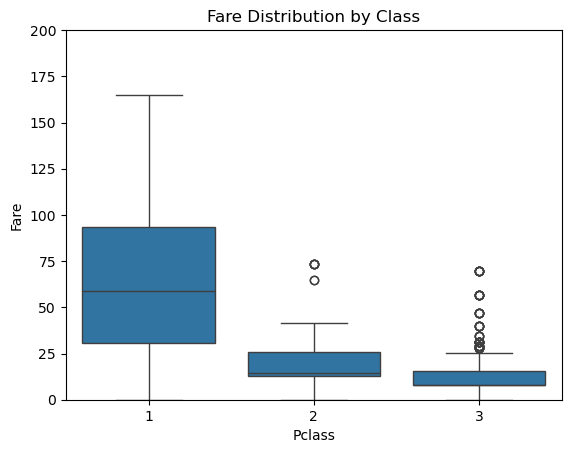

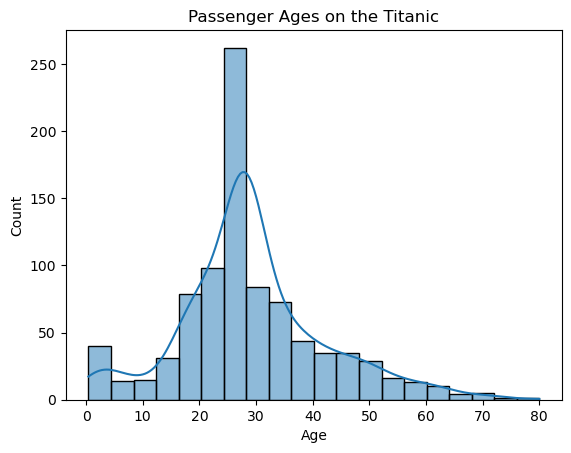

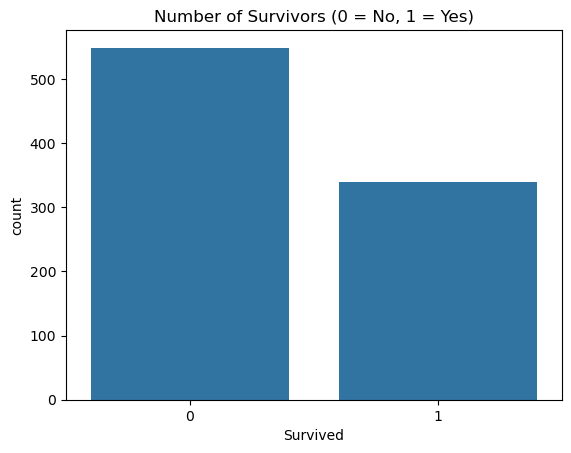

In [3]:
# Chart 1: Boxplot (Fare by Class)
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.ylim(0, 200) # Cutting off outliers to see the box clearly
plt.title('Fare Distribution by Class')
plt.show()

# Chart 2: Histogram (Age Distribution)
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Passenger Ages on the Titanic')
plt.show()

# Chart 3: Count Plot (Survival Count)
# This shows how many people survived vs. those who did not.
sns.countplot(x='Survived', data=df)
plt.title('Number of Survivors (0 = No, 1 = Yes)')
plt.show()